# 09_Polynomial Regression

# Polynomial Regression

Linear Regression에서는 Input과 Output 사이의 관계를 직선으로 표현하였다.

그러나 실제 Data의 관계가 항상 직선으로 나타나는 것은 아니다.

이번에는 `polynomial_data.csv`를 이용하여 다음 Problem을 생각해 보자.

> $x$를 이용하여 $y$를 예측한다.

어떤 Regression Method를 사용할지 결정하기 전에 먼저 Data를 관찰한다.

> Data → Pattern → Model

In [1]:
from google.colab import drive

# Google Drive를 Colab에 Mount
drive.mount('/content/drive')

# 강의용 Data가 저장된 Folder

data_path = "/content/drive/My Drive/Colab Notebooks/0_ML/Input/"

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Data 읽기
df = pd.read_csv(data_path+"another2_data.csv")

# Data 확인
display(df.head())

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

,x,y
0,-1.254599,4.817138
1,4.507143,10.890661
2,2.319939,2.683807
3,0.986585,5.544241
4,-3.439814,4.250485


Shape: (200, 2)
Columns: ['x', 'y']


## Observe the Relationship

먼저 $x$와 $y$의 관계를 Scatter Plot으로 확인한다.

다음 질문을 생각해 보자.

- $x$와 $y$ 사이에 관계가 있는가?
- 하나의 직선으로 표현할 수 있는가?
- Curve의 방향이 몇 번 바뀌는가?
- 어떤 정도의 Polynomial Model이 필요해 보이는가?

먼저 Data의 Pattern을 관찰한 후 Model을 선택한다.

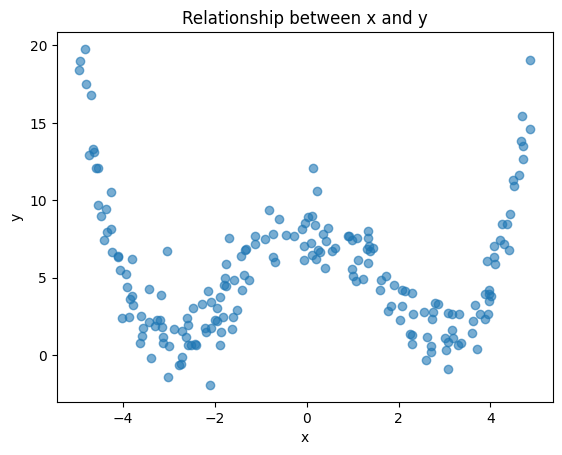

In [3]:
# x와 y의 관계 확인
plt.scatter(
    df["x"],
    df["y"],
    alpha=0.6
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Relationship between x and y")

plt.show()

## Observe the Pattern

Scatter Plot을 보면 $x$와 $y$ 사이에는 분명한 관계가 있다.

그러나 이 관계를 하나의 Straight Line으로 표현하기는 어렵다.

Data의 전체적인 Curve를 관찰하면 여러 번 방향이 변하는 Pattern이 나타난다.

따라서 다음과 같은 Polynomial Function으로 이 관계를 표현해 보자.

$$
\hat{y}
=
w_1x+w_2x^2+w_3x^3+w_4x^4+b
$$

즉, Degree 4 Polynomial Regression을 적용한다.

## Polynomial Features

현재 Input Feature는 하나이다.

$$
x
$$

Degree 4 Polynomial Regression을 위해 $x$로부터 새로운 Features를 만든다.

$$
x,\;x^2,\;x^3,\;x^4
$$

그러면 하나의 Input Feature가 네 개의 Features로 변환된다.

$$
X
=
[x]
$$

에서

$$
X_{poly}
=
[x,\;x^2,\;x^3,\;x^4]
$$

로 변환된다.

In [4]:
from sklearn.preprocessing import PolynomialFeatures

# Original Input
X = df[["x"]]
y = df["y"]

# Degree 4 Polynomial Features 생성
poly = PolynomialFeatures(
    degree=4,
    include_bias=False
)

X_poly = poly.fit_transform(X)

# 변환 결과 확인
print("Original X")
display(X.head())

print("Polynomial Features")
print(X_poly[:5])

Original X


,x
0,-1.254599
1,4.507143
2,2.319939
3,0.986585
4,-3.439814


Polynomial Features
[[ -1.25459881   1.57401818  -1.97476134   2.47753322]
 [  4.50714306  20.3143386   91.55963032 412.67235277]
 [  2.31993942   5.3821189   12.4861898   28.96720389]
 [  0.98658484   0.97334965   0.96029201   0.94740954]
 [ -3.4398136   11.83231757 -40.70096685 140.00373913]]


## Polynomial Regression

변환된 Features를 이용하여 Linear Regression을 수행한다.

Input Features:

$$
x,\;x^2,\;x^3,\;x^4
$$

Model:

$$
\hat{y}
=
w_1x+w_2x^2+w_3x^3+w_4x^4+b
$$

Polynomial Regression이라는 새로운 Regression Algorithm을 사용하는 것이 아니라,

Polynomial Features를 만든 후 Linear Regression을 적용하는 것이다.

In [5]:
from sklearn.linear_model import LinearRegression

# Model 생성
model = LinearRegression()

# Model Training
model.fit(X_poly, y)

print("Training Complete")

Training Complete


## Learned Parameters

Training을 통해 네 개의 Weight와 하나의 Bias가 결정된다.

$$
\hat{y}
=
w_1x+w_2x^2+w_3x^3+w_4x^4+b
$$

학습된 Parameters를 확인해 보자.

In [ ]:
# 학습된 Weight와 Bias
for i, weight in enumerate(model.coef_, start=1):
    print(f"Weight of x^{i}: {weight:.4f}")

print(f"Bias: {model.intercept_:.4f}")

## Regression Curve

학습된 Polynomial Regression Model이 Data의 Pattern을 얼마나 잘 표현하는지 확인해 보자.

Actual Data와 학습된 Regression Curve를 함께 그린다.

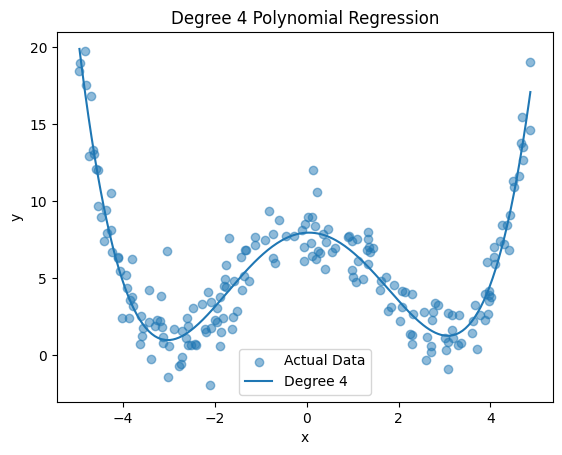

In [6]:
# Curve를 그리기 위한 x 생성
x_curve = np.linspace(
    df["x"].min(),
    df["x"].max(),
    300
)

X_curve = pd.DataFrame({"x": x_curve})

# Polynomial Features로 변환
X_curve_poly = poly.transform(X_curve)

# Prediction
y_curve = model.predict(X_curve_poly)

# Actual Data와 Regression Curve
plt.scatter(
    df["x"],
    y,
    alpha=0.5,
    label="Actual Data"
)

plt.plot(
    x_curve,
    y_curve,
    label="Degree 4"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Degree 4 Polynomial Regression")
plt.legend()

plt.show()

## Evaluation

Regression Curve를 보면 Degree 4 Model이 Data의 전체적인 Pattern을 잘 표현하고 있는지 시각적으로 확인할 수 있다.

이제 MSE와 $R^2$를 이용하여 Model을 평가한다.

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

# Training Data에 대한 Prediction
y_pred = model.predict(X_poly)

# Evaluation
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print("MSE:", mse)
print("R-squared:", r2)

MSE: 2.054814122222237
R-squared: 0.8816082563655682


## Polynomial Regression as Multiple Linear Regression

Degree 4 Polynomial Regression의 Model은 다음과 같다.

$$
\hat{y}
=
w_1x+w_2x^2+w_3x^3+w_4x^4+b
$$

겉으로 보면 Nonlinear Regression처럼 보인다.

그러나 새로운 Variables를 다음과 같이 정의해 보자.

$$
z_1=x
$$

$$
z_2=x^2
$$

$$
z_3=x^3
$$

$$
z_4=x^4
$$

그러면 Model은

$$
\hat{y}
=
w_1z_1+w_2z_2+w_3z_3+w_4z_4+b
$$

가 된다.

이 식은 $z_1$, $z_2$, $z_3$, $z_4$를 Input Features로 사용하는 Multiple Linear Regression과 동일하다.

즉, Polynomial Regression의 핵심은

> Polynomial Features 생성 → Multiple Linear Regression

이다.

In [8]:
# Original Input
X = df[["x"]]

# Degree 4 Polynomial Features 생성
poly = PolynomialFeatures(
    degree=4,
    include_bias=False
)

X_poly = poly.fit_transform(X)

# Polynomial Features를 DataFrame으로 변환
X_poly_df = pd.DataFrame(
    X_poly,
    columns=["x", "x^2", "x^3", "x^4"]
)

# 원래 Data와 변환된 Data 비교
display(X.head())
display(X_poly_df.head())

,x
0,-1.254599
1,4.507143
2,2.319939
3,0.986585
4,-3.439814


,x,x^2,x^3,x^4
0,-1.254599,1.574018,-1.974761,2.477533
1,4.507143,20.314339,91.559630,412.672353
2,2.319939,5.382119,12.486190,28.967204
3,0.986585,0.973350,0.960292,0.947410
4,-3.439814,11.832318,-40.700967,140.003739


## What Happened to the Data?

원래 Input에는 하나의 Feature만 있었다.

$$
X=[x]
$$

Polynomial Transformation을 수행한 후에는 네 개의 Features가 만들어졌다.

$$
X_{poly}
=
[x,\;x^2,\;x^3,\;x^4]
$$

예를 들어 $x=2$라면 하나의 Input

$$
[2]
$$

가 다음과 같이 변환된다.

$$
[2,\;4,\;8,\;16]
$$

따라서 Degree 4 Polynomial Regression은 네 개의 Input Features를 가진 Regression Problem으로 바뀐다.

In [9]:
# Polynomial Features를 이용한 Linear Regression
model = LinearRegression()

model.fit(X_poly_df, y)

# 학습된 Parameters 확인
weights = pd.DataFrame({
    "Feature": X_poly_df.columns,
    "Weight": model.coef_
})

display(weights)

print("Bias:", model.intercept_)

,Feature,Weight
0,x,0.142000
1,x^2,-1.471358
2,x^3,-0.010362
3,x^4,0.079215


Bias: 7.9554206208246745


## Compare with Multiple Linear Regression

08강의 Multiple Linear Regression에서는 다음과 같은 Model을 사용하였다.

$$
\hat{y}
=
w_1x_1+w_2x_2+w_3x_3+b
$$

09강의 Degree 4 Polynomial Regression은 다음과 같다.

$$
\hat{y}
=
w_1x+w_2x^2+w_3x^3+w_4x^4+b
$$

두 Model의 구조는 본질적으로 같다.

차이는 Input Features가 어떻게 만들어졌는가에 있다.

Multiple Linear Regression에서는 원래 Data에 존재하는 여러 Features를 사용하였다.

$$
x_1,\;x_2,\;x_3
$$

Polynomial Regression에서는 하나의 Variable $x$로부터 새로운 Features를 만들었다.

$$
x,\;x^2,\;x^3,\;x^4
$$

따라서 Polynomial Regression은 Feature Transformation을 수행한 후 Linear Regression을 적용하는 방법으로 이해할 수 있다.

In [10]:
# PolynomialFeatures를 사용하지 않고 직접 같은 Features 생성
X_manual = pd.DataFrame({
    "x": df["x"],
    "x^2": df["x"] ** 2,
    "x^3": df["x"] ** 3,
    "x^4": df["x"] ** 4
})

# 일반 Multiple Linear Regression 수행
manual_model = LinearRegression()
manual_model.fit(X_manual, y)

# PolynomialFeatures를 사용한 Model과 비교
print("PolynomialFeatures Model")
print("Weights:", model.coef_)
print("Bias:", model.intercept_)

print()

print("Manually Created Features Model")
print("Weights:", manual_model.coef_)
print("Bias:", manual_model.intercept_)

PolynomialFeatures Model
Weights: [ 0.14199976 -1.47135763 -0.01036243  0.07921476]
Bias: 7.9554206208246745

Manually Created Features Model
Weights: [ 0.14199976 -1.47135763 -0.01036243  0.07921476]
Bias: 7.955420620824703


## Same Result

`PolynomialFeatures`를 이용한 경우와

$x$, $x^2$, $x^3$, $x^4$를 직접 만들어 Multiple Linear Regression을 수행한 경우의 Weight와 Bias가 동일한 것을 확인할 수 있다.

따라서 Polynomial Regression에서 새로운 것은 Regression Algorithm 자체가 아니다.

중요한 것은 Input을 어떻게 표현하는가이다.

$$
x
\rightarrow
(x,\;x^2,\;x^3,\;x^4)
\rightarrow
LinearRegression
$$

즉,

> Polynomial Regression = Feature Transformation + Linear Regression

으로 이해할 수 있다.

## Polynomial Regression and Multiple Linear Regression

앞에서는 `PolynomialFeatures`를 이용하여 Degree 4 Polynomial Regression을 수행하였다.

이번에는 새로운 Features를 직접 만든다.

$$
x_1=x,\qquad
x_2=x^2,\qquad
x_3=x^3,\qquad
x_4=x^4
$$

그리고 이 네 Features를 이용하여 Multiple Linear Regression을 수행한다.

$$
\hat{y}
=
w_1x_1+w_2x_2+w_3x_3+w_4x_4+b
$$

두 방법으로 얻은 Regression Curve를 비교해 보자.

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


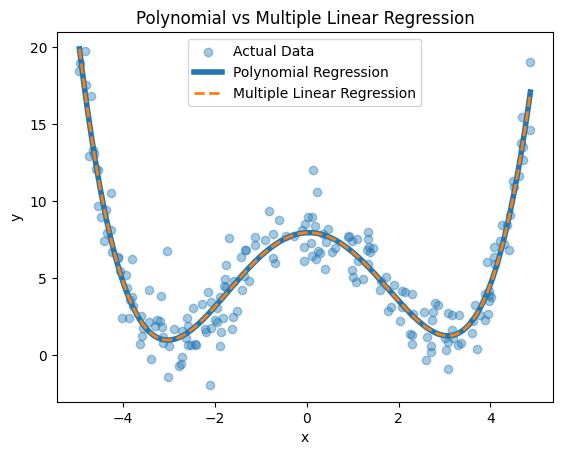

In [11]:
# Multiple Linear Regression을 위한 Features 직접 생성
X_multiple = pd.DataFrame({
    "x1": df["x"],
    "x2": df["x"] ** 2,
    "x3": df["x"] ** 3,
    "x4": df["x"] ** 4
})

# Multiple Linear Regression
multiple_model = LinearRegression()
multiple_model.fit(X_multiple, y)

# Curve를 그리기 위한 Input
x_curve = np.linspace(
    df["x"].min(),
    df["x"].max(),
    300
)

# Polynomial Regression Prediction
X_curve = pd.DataFrame({"x": x_curve})
X_curve_poly = poly.transform(X_curve)
y_poly = model.predict(X_curve_poly)

# Multiple Linear Regression Prediction
X_curve_multiple = pd.DataFrame({
    "x1": x_curve,
    "x2": x_curve ** 2,
    "x3": x_curve ** 3,
    "x4": x_curve ** 4
})

y_multiple = multiple_model.predict(X_curve_multiple)

# 두 결과 비교
plt.scatter(
    df["x"],
    y,
    alpha=0.4,
    label="Actual Data"
)

plt.plot(
    x_curve,
    y_poly,
    linewidth=4,
    label="Polynomial Regression"
)

plt.plot(
    x_curve,
    y_multiple,
    linestyle="--",
    linewidth=2,
    label="Multiple Linear Regression"
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Polynomial vs Multiple Linear Regression")
plt.legend()

plt.show()

### HW_09

`Input/another3_data.csv`를 이용하여 Polynomial Regression을 수행하고 다음 질문에 답하시오.

- Scatter Plot의 형태를 보고 적절하다고 판단한 Polynomial Degree를 적으시오.
- 선택한 Degree로 학습한 Model의 MSE를 소수점 셋째 자리까지 적으시오.
- Model의 $R^2$를 소수점 셋째 자리까지 적으시오.
- 학습된 Polynomial Regression Equation의 각 Weight와 Bias를 소수점 셋째 자리까지 적으시오.
- 같은 Polynomial Features를 직접 생성하여 Multiple Linear Regression을 수행했을 때 두 Model의 Prediction이 같은지 `Yes` 또는 `No`로 답하시오.

답만 제출하시오.